# Netflix Movies & TV Shows - EDA
**Gray Interface '26 | Task 1**

## Importing the dependencies

In [105]:
# Installing required libraries
!pip install kagglehub wordcloud --quiet


In [106]:
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from itertools import combinations
from collections import Counter


## Loading the Dataset

In [107]:
# Downloading the Netflix dataset directly from Kaggle
path = kagglehub.dataset_download("shivamb/netflix-shows")

# Loading the CSV into a DataFrame
df = pd.read_csv(os.path.join(path, "netflix_titles.csv"))

print("Dataset Shape:", df.shape)
df.head()


Using Colab cache for faster access to the 'netflix-shows' dataset.
Dataset Shape: (8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## Basic Dataset Information

In [108]:
# Column names and data types
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [109]:
# Missing values in each column
df.isnull().sum()


,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [110]:
# Statistical summary of numerical columns
df.describe()


,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


## Data Cleaning

In [111]:
# Filling missing values in text columns with 'Unknown'
df['director'] = df['director'].fillna('Unknown')
df['cast']     = df['cast'].fillna('Unknown')
df['country']  = df['country'].fillna('Unknown')
df['rating']   = df['rating'].fillna('Unknown')

# Dropping rows where date_added is missing (very few, safe to drop)
df = df.dropna(subset=['date_added'])



## Feature Engineering

### Fixing the Duration Column

In [112]:
# 'duration' contains mixed units: '90 min' for movies, '3 Seasons' for TV shows
# Extract just the number from the string
df['duration_int'] = df['duration'].str.extract(r'(\d+)').astype(float)

# Creating separate columns for movies and TV shows
df['movie_minutes'] = df['duration_int'].where(df['type'] == 'Movie')
df['tv_seasons']    = df['duration_int'].where(df['type'] == 'TV Show')

# Previewing the result
df[['type', 'duration', 'movie_minutes', 'tv_seasons']].head(8)


,type,duration,movie_minutes,tv_seasons
0,Movie,90 min,90.0,NaN
1,TV Show,2 Seasons,NaN,2.0
2,TV Show,1 Season,NaN,1.0
3,TV Show,1 Season,NaN,1.0
4,TV Show,2 Seasons,NaN,2.0
5,TV Show,1 Season,NaN,1.0
6,Movie,91 min,91.0,NaN
7,Movie,125 min,125.0,NaN


### Parsing the Date Column

In [113]:
# Converting date_added from string to proper datetime format
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), format='%B %d, %Y', errors='coerce')

# Extracting useful time features
df['year_added']  = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month
df['day_of_week'] = df['date_added'].dt.day_name()

# Previewing the result
df[['title', 'date_added', 'year_added', 'month_added', 'day_of_week']].head()


,title,date_added,year_added,month_added,day_of_week
0,Dick Johnson Is Dead,2021-09-25,2021,9,Saturday
1,Blood & Water,2021-09-24,2021,9,Friday
2,Ganglands,2021-09-24,2021,9,Friday
3,Jailbirds New Orleans,2021-09-24,2021,9,Friday
4,Kota Factory,2021-09-24,2021,9,Friday


### Splitting Comma-Separated Columns

In [114]:
# Columns like 'listed_in', 'cast', 'country' have multiple values joined by commas
# We split and explode them so each value gets its own row for counting

genres    = df['listed_in'].str.split(',').explode().str.strip()
countries = df['country'].str.split(',').explode().str.strip().replace('Unknown', None).dropna()
cast      = df['cast'].str.split(',').explode().str.strip().replace('Unknown', None).dropna()
directors = df['director'].str.split(',').explode().str.strip().replace('Unknown', None).dropna()

print("Unique genres:", genres.nunique())
print("Unique countries:", countries.nunique())


Unique genres: 42
Unique countries: 123


## Data Visualization

### Plot 1 - Movies vs TV Shows

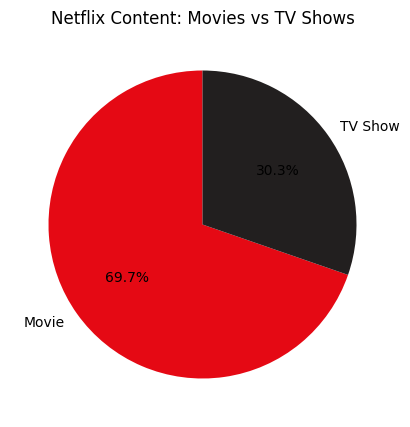

type
Movie      6131
TV Show    2666
Name: count, dtype: int64


In [115]:
# Counting how many titles are Movies vs TV Shows
type_counts = df['type'].value_counts()

plt.figure(figsize=(6, 5))
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%',
        colors=['#E50914', '#221F1F'], startangle=90)
plt.title('Netflix Content: Movies vs TV Shows')
plt.show()

print(type_counts)


### Plot 2 - Content Added Each Year

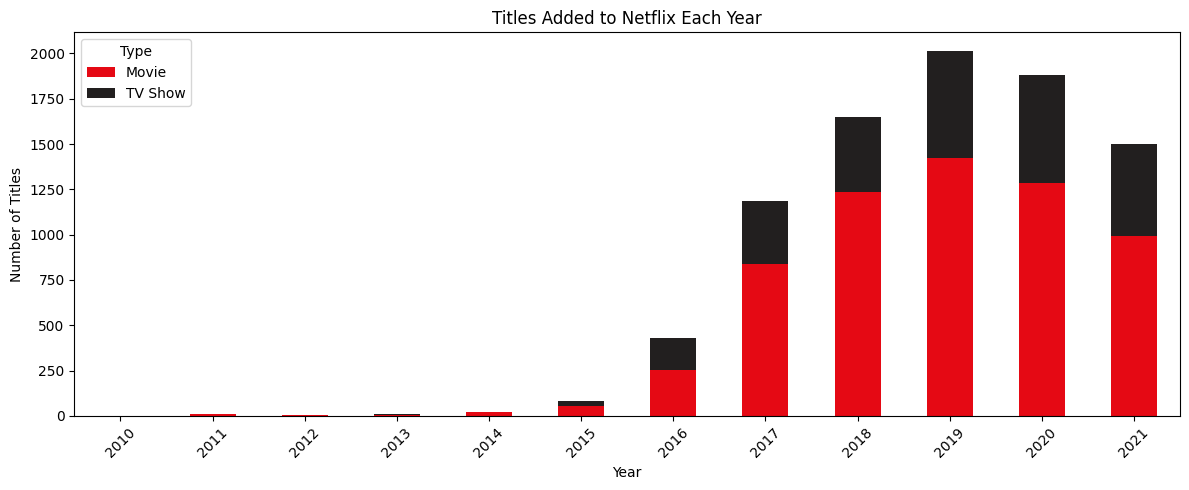

In [116]:
# How many titles were added each year, split by type
yearly = df[df['year_added'] >= 2010].groupby(['year_added', 'type']).size().unstack(fill_value=0)

yearly.plot(kind='bar', stacked=True, figsize=(12, 5), color=['#E50914', '#221F1F'])
plt.title('Titles Added to Netflix Each Year')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.legend(title='Type')
plt.tight_layout()
plt.show()


### Plot 3 - Which Month Gets the Most Content?

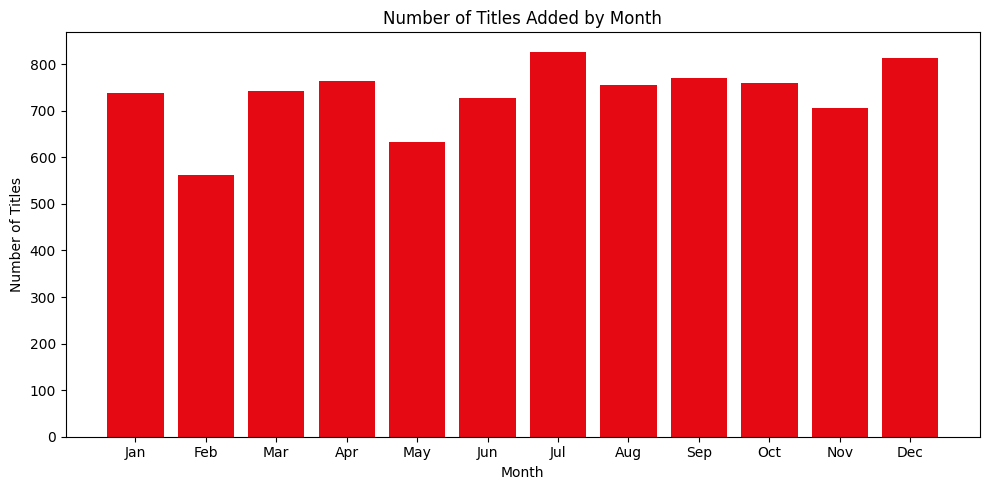

In [117]:
# Counting titles added per month
month_counts = df['month_added'].value_counts().sort_index()

# Using month names for x-axis
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(10, 5))
plt.bar(month_names, month_counts.values, color='#E50914')
plt.title('Number of Titles Added by Month')
plt.xlabel('Month')
plt.ylabel('Number of Titles')
plt.tight_layout()
plt.show()


### Plot 4 - Top 10 Genres

/tmp/ipykernel_5615/3346211106.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette='Reds_r')


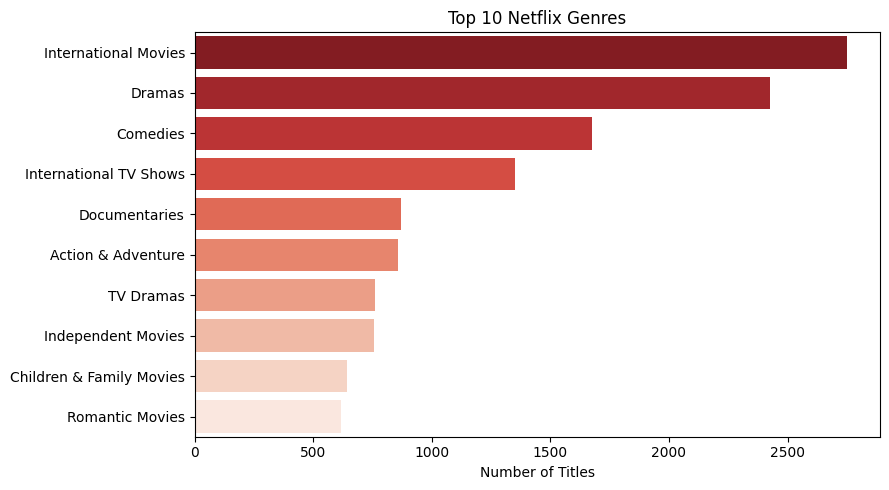

In [118]:
# Getting the 10 most common genres
top_genres = genres.value_counts().head(10)

plt.figure(figsize=(9, 5))
sns.barplot(x=top_genres.values, y=top_genres.index, palette='Reds_r')
plt.title('Top 10 Netflix Genres')
plt.xlabel('Number of Titles')
plt.ylabel('')
plt.tight_layout()
plt.show()


### Plot 5 - Top 10 Countries Producing Content

/tmp/ipykernel_5615/1813417413.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='OrRd_r')


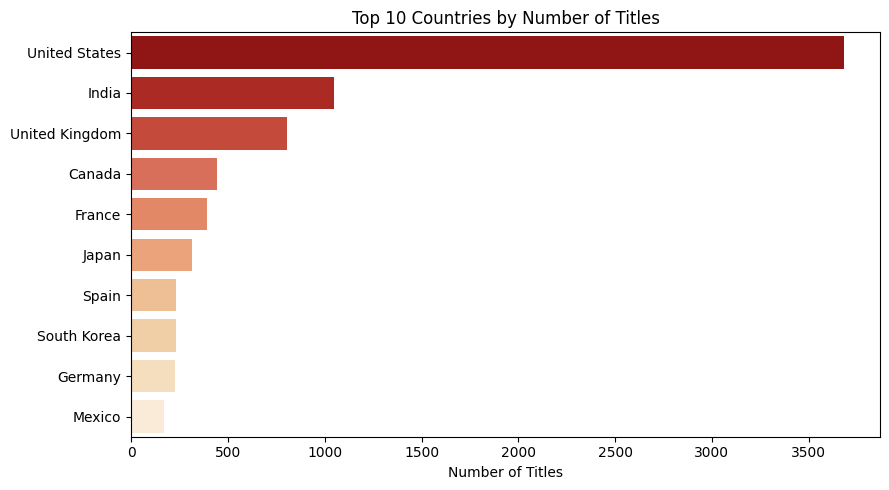

In [119]:
# Which countries produce the most Netflix content?
top_countries = countries.value_counts().head(10)

plt.figure(figsize=(9, 5))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='OrRd_r')
plt.title('Top 10 Countries by Number of Titles')
plt.xlabel('Number of Titles')
plt.ylabel('')
plt.tight_layout()
plt.show()


### Plot 6 - Movie Duration Distribution

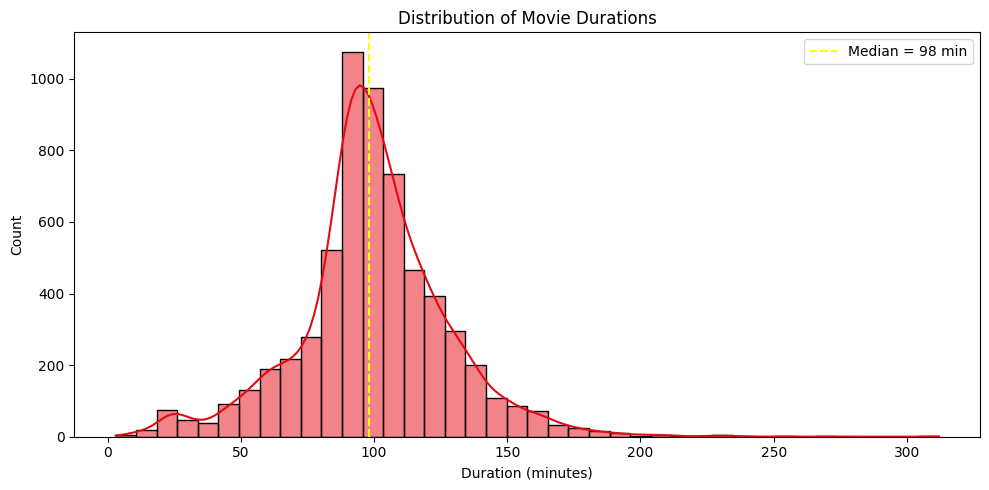

In [120]:
# Distribution of movie lengths (in minutes)
movies = df[df['type'] == 'Movie'].dropna(subset=['movie_minutes'])

plt.figure(figsize=(10, 5))
sns.histplot(movies['movie_minutes'], bins=40, kde=True, color='#E50914')
plt.axvline(movies['movie_minutes'].median(), color='yellow', linestyle='--',
            label=f"Median = {movies['movie_minutes'].median():.0f} min")
plt.title('Distribution of Movie Durations')
plt.xlabel('Duration (minutes)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()


### Plot 7 - TV Show Seasons Distribution

/tmp/ipykernel_5615/3203016576.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=season_counts.index.astype(int), y=season_counts.values, palette='flare')


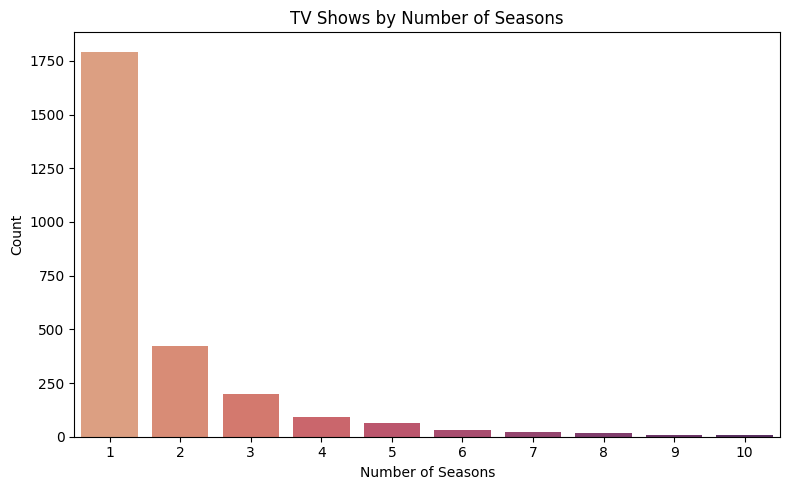

In [121]:
# How many seasons do TV shows on Netflix have?
tv_shows = df[df['type'] == 'TV Show'].dropna(subset=['tv_seasons'])
season_counts = tv_shows['tv_seasons'].value_counts().sort_index().head(10)

plt.figure(figsize=(8, 5))
sns.barplot(x=season_counts.index.astype(int), y=season_counts.values, palette='flare')
plt.title('TV Shows by Number of Seasons')
plt.xlabel('Number of Seasons')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


### Plot 8 - Content Ratings Distribution

/tmp/ipykernel_5615/1538613296.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rating_counts.index, y=rating_counts.values, palette='rocket_r')


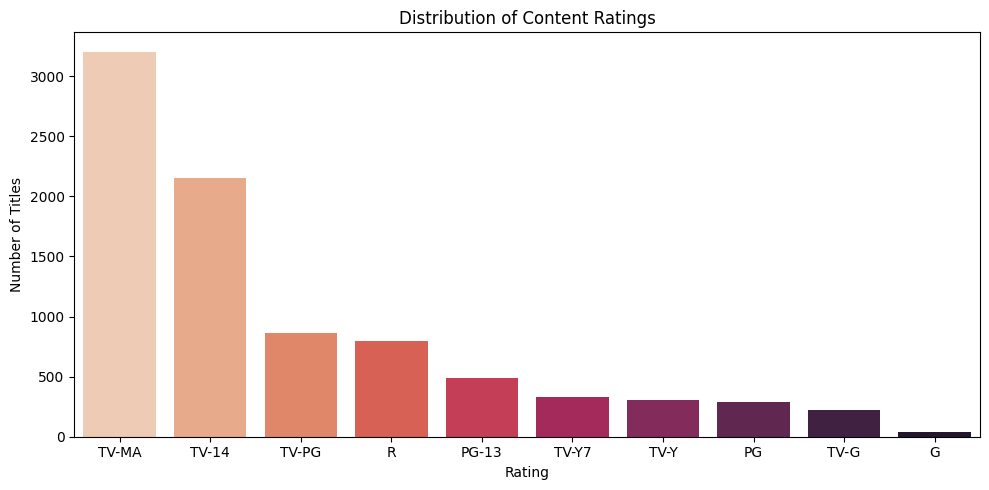

In [122]:
# Which age ratings are most common?
valid_ratings = ['G','PG','PG-13','R','TV-Y','TV-Y7','TV-G','TV-PG','TV-14','TV-MA']
rating_counts = df[df['rating'].isin(valid_ratings)]['rating'].value_counts()

plt.figure(figsize=(10, 5))
sns.barplot(x=rating_counts.index, y=rating_counts.values, palette='rocket_r')
plt.title('Distribution of Content Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Titles')
plt.tight_layout()
plt.show()


### Plot 9 - Top 15 Actors

/tmp/ipykernel_5615/3765719553.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_actors.values, y=top_actors.index, palette='magma_r')


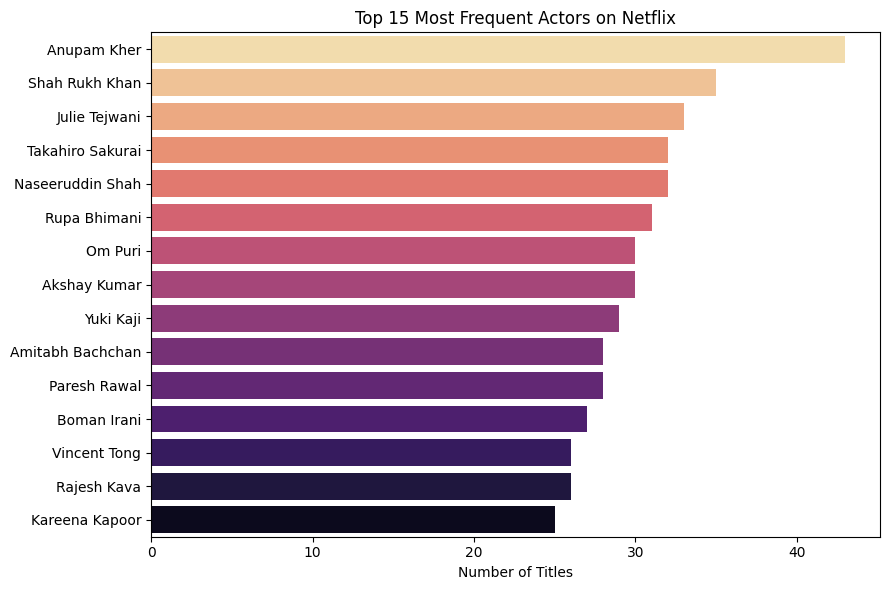

In [123]:
# Which actors appear in the most Netflix titles?
top_actors = cast.value_counts().head(15)

plt.figure(figsize=(9, 6))
sns.barplot(x=top_actors.values, y=top_actors.index, palette='magma_r')
plt.title('Top 15 Most Frequent Actors on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('')
plt.tight_layout()
plt.show()


### Plot 10 - Top 10 Directors

/tmp/ipykernel_5615/1024156033.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_directors.values, y=top_directors.index, palette='viridis_r')


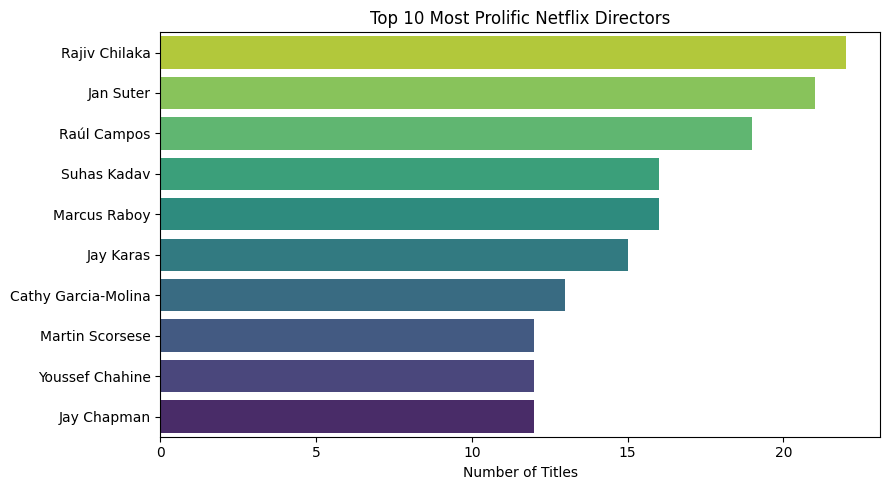

In [124]:
# Which directors have directed the most Netflix titles?
top_directors = directors.value_counts().head(10)

plt.figure(figsize=(9, 5))
sns.barplot(x=top_directors.values, y=top_directors.index, palette='viridis_r')
plt.title('Top 10 Most Prolific Netflix Directors')
plt.xlabel('Number of Titles')
plt.ylabel('')
plt.tight_layout()
plt.show()


### Plot 11 - Genre Co-occurrence Heatmap

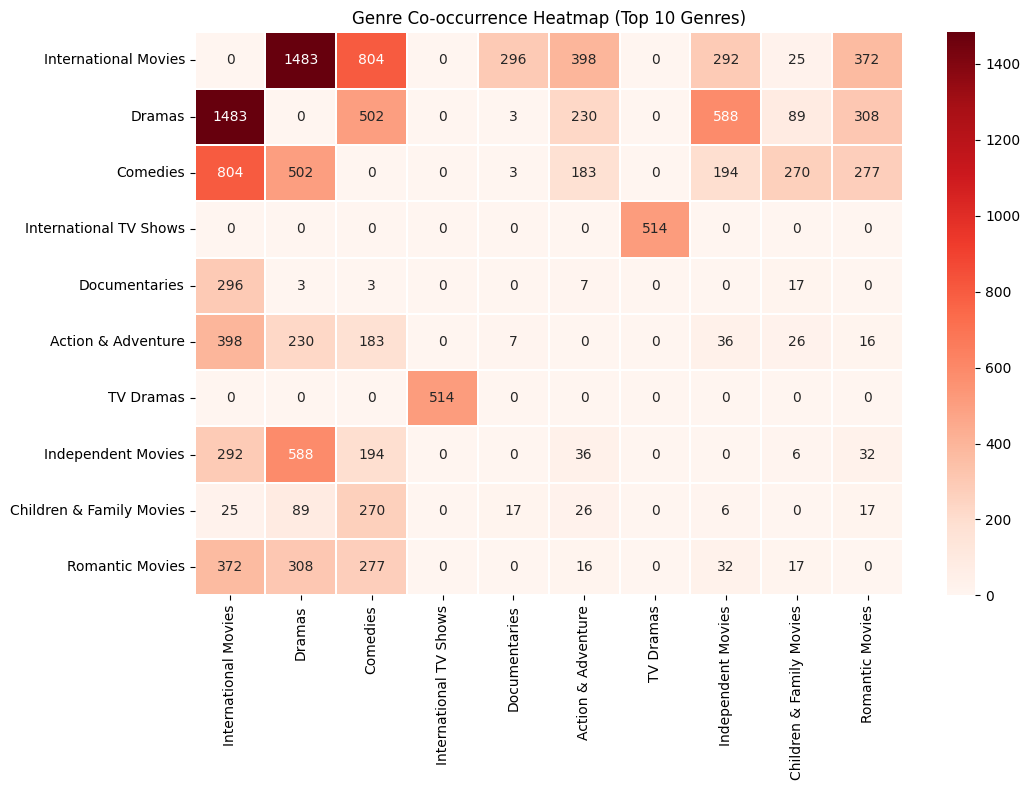

In [125]:
# Finding which genres frequently appear together in the same title
top_genre_list = genres.value_counts().head(10).index.tolist()

# Building a co-occurrence matrix
co_matrix = pd.DataFrame(0, index=top_genre_list, columns=top_genre_list)

for genre_string in df['listed_in']:
    title_genres = [g.strip() for g in genre_string.split(',') if g.strip() in top_genre_list]
    for g1, g2 in combinations(sorted(title_genres), 2):
        co_matrix.loc[g1, g2] += 1
        co_matrix.loc[g2, g1] += 1

plt.figure(figsize=(11, 8))
sns.heatmap(co_matrix, annot=True, fmt='d', cmap='Reds', linewidths=0.3)
plt.title('Genre Co-occurrence Heatmap (Top 10 Genres)')
plt.tight_layout()
plt.show()


### Plot 12 - Which Day Does Netflix Upload the Most?

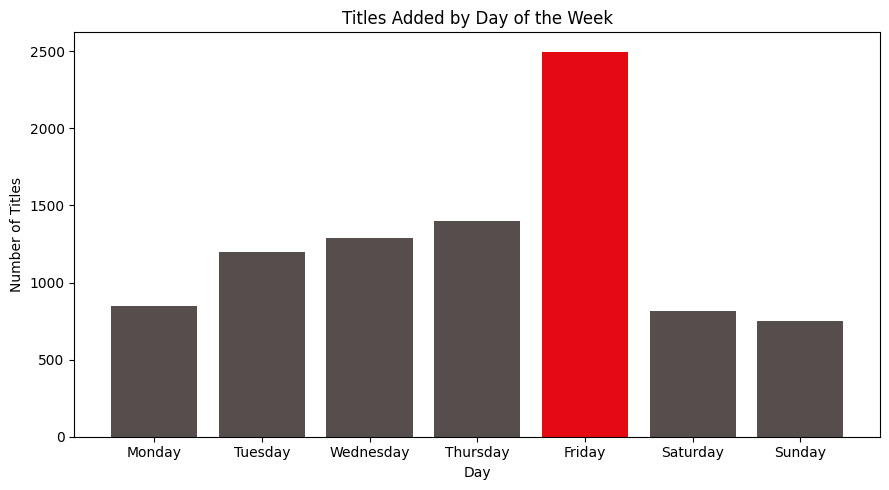

In [126]:
# Counting how many titles are added on each day of the week
day_order   = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts  = df['day_of_week'].value_counts().reindex(day_order)

plt.figure(figsize=(9, 5))
bars = plt.bar(day_counts.index, day_counts.values,
               color=['#E50914' if d == 'Friday' else '#564D4D' for d in day_order])
plt.title('Titles Added by Day of the Week')
plt.xlabel('Day')
plt.ylabel('Number of Titles')
plt.tight_layout()
plt.show()


### Plot 13 - WordCloud: Horror vs Comedy Descriptions

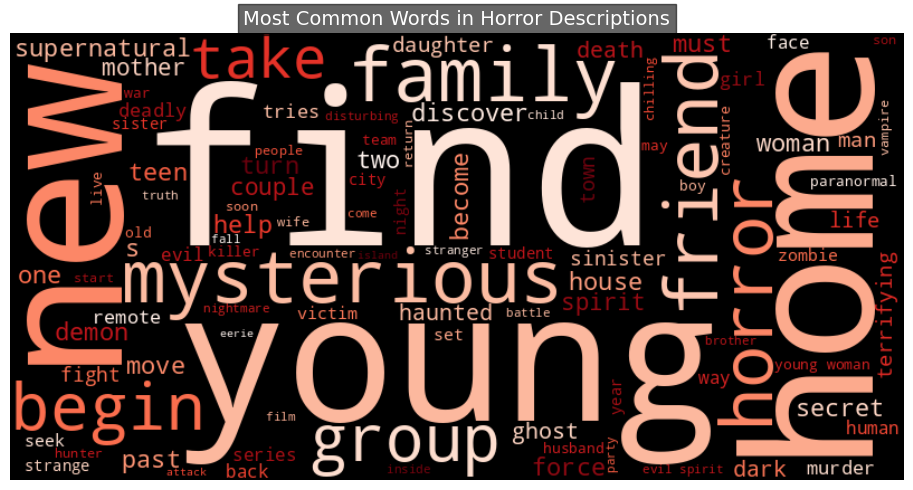

In [127]:
# Getting all descriptions for Horror and Comedy titles
horror_text = ' '.join(df[df['listed_in'].str.contains('Horror', na=False)]['description'].dropna())
comedy_text = ' '.join(df[df['listed_in'].str.contains('Comedies', na=False)]['description'].dropna())

# Generate and display Horror WordCloud
horror_wc = WordCloud(width=800, height=400, background_color='black',
                      colormap='Reds', max_words=100).generate(horror_text)

plt.figure(figsize=(11, 5))
plt.imshow(horror_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Horror Descriptions', fontsize=14, color='white',
          bbox=dict(facecolor='black', alpha=0.6))
plt.tight_layout()
plt.show()


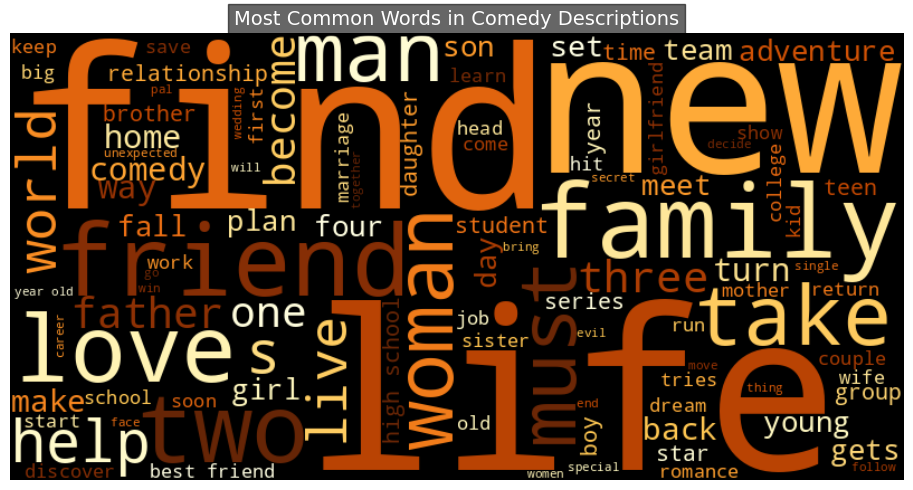

In [128]:
# Generate and display Comedy WordCloud
comedy_wc = WordCloud(width=800, height=400, background_color='black',
                      colormap='YlOrBr', max_words=100).generate(comedy_text)

plt.figure(figsize=(11, 5))
plt.imshow(comedy_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Comedy Descriptions', fontsize=14, color='white',
          bbox=dict(facecolor='black', alpha=0.6))
plt.tight_layout()
plt.show()


### Plot 14 - Actual vs Predicted (Bonus: Release Year vs Content Count)

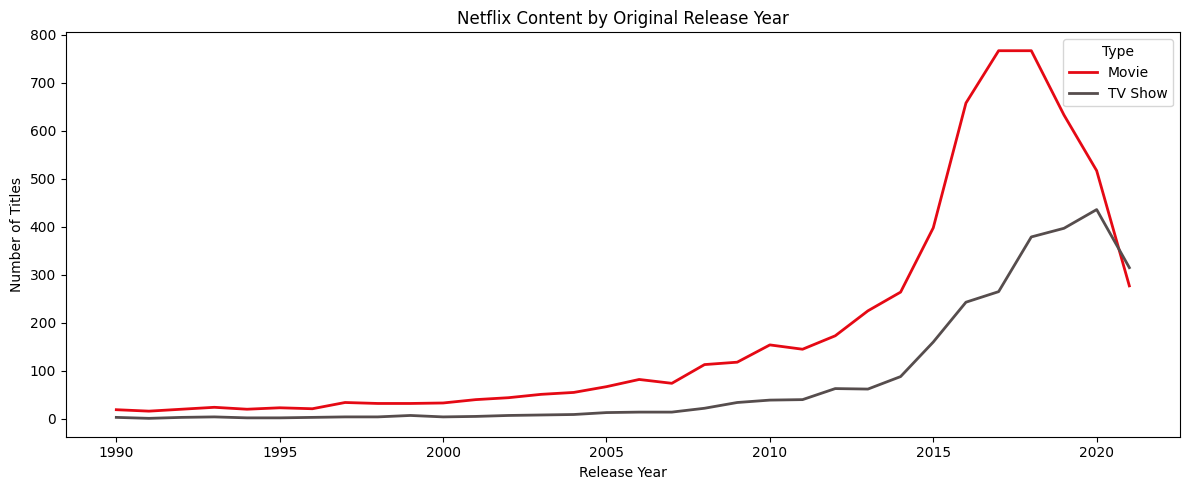

In [129]:
# How has the release year of content on Netflix changed over time?
release_trend = df.groupby(['release_year', 'type']).size().unstack(fill_value=0)
release_trend = release_trend[release_trend.index >= 1990]

release_trend.plot(kind='line', figsize=(12, 5), color=['#E50914', '#564D4D'], linewidth=2)
plt.title('Netflix Content by Original Release Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.legend(title='Type')
plt.tight_layout()
plt.show()


## Key Findings

| # | Finding |
|---|---------|
| 1 | ~70% of Netflix's catalogue is Movies; TV Shows are a growing minority |
| 2 | Netflix added the most content between 2017–2019; growth slowed after 2020 |
| 3 | January and December see the highest content additions |
| 4 | **Friday** is the most common upload day — timed for the weekend audience |
| 5 | International Movies & Dramas are the top two genres |
| 6 | USA produces the most content; India is a strong #2 (post-2018 surge) |
| 7 | Most movies are 80–110 minutes; most TV shows run only 1 season |
| 8 | TV-MA (adult content) dominates the ratings — Netflix skews 18+ |
| 9 | Horror descriptions use dark/survival words; Comedy leans on family & relationships |
| 10 | Dramas + International Movies co-occur most often — almost always tagged together |
